In [1]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import streamlit as st 
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
import os 
from langchain_google_genai import ChatGoogleGenerativeAI
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel, Field
import operator
from langgraph.graph import StateGraph,START, END,MessagesState

from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver
# model=ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash-lite",   # or gemini-2.0-pro, 1.5-pro, etc.
#     temperature=0.2)
#from langchain_core.messages.utils import trim_messages,count_tokens_approximately
model=ChatOpenAI()

In [2]:
from langchain.messages import RemoveMessage

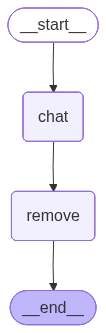

In [15]:
def call_model(state:MessagesState):
    #msg=trim_messages(state["messages"],strategy='last',token_counter=count_tokens_approximately,max_tokens=max_tokens)
    msg=state["messages"]
    #print("current token count is ",count_tokens_approximately(messages=msg))
    response =model.invoke(msg)
    return {"messages":[response]}
def remove_chat(state:MessagesState):
    #msg=trim_messages(state["messages"],strategy='last',token_counter=count_tokens_approximately,max_tokens=max_tokens)
    msg=state["messages"]
    if len(msg) >10:
        to_remove=msg[:6]
        return {'messages':[RemoveMessage(id=m.id) for m in to_remove ]}
    #print("current token count is ",count_tokens_approximately(messages=msg))
    #response =model.invoke(msg)
    #return {"messages":[response]}
    else:
        return {}
graph=StateGraph(MessagesState)
checkpointer=InMemorySaver()
graph.add_node('chat',call_model)
graph.add_node('remove',remove_chat)
graph.add_edge(START,'chat')
graph.add_edge('chat','remove')
graph.add_edge('remove',END)
workflow=graph.compile(checkpointer=checkpointer)
workflow

In [16]:
initial_stage={'messages':[{'role':'user','content':'whats my name'}]}
thread = {"configurable": {"thread_id": "1"}}
workflow.invoke(initial_stage,config=thread) 
initial_stage={'messages':[{'role':'user','content':'whats is AI'}]}
workflow.invoke(initial_stage,config=thread)
initial_stage={'messages':[{'role':'user','content':'whats is langchain'}]}
workflow.invoke(initial_stage,config=thread)
initial_stage={'messages':[{'role':'user','content':'whats is langgraph'}]}
workflow.invoke(initial_stage,config=thread)
initial_stage={'messages':[{'role':'user','content':'whats is data science'}]}
workflow.invoke(initial_stage,config=thread)
initial_stage={'messages':[{'role':'user','content':'whats is data Engineering'}]}
workflow.invoke(initial_stage,config=thread)
initial_stage={'messages':[{'role':'user','content':'whats is data'}]}
workflow.invoke(initial_stage,config=thread)

{'messages': [HumanMessage(content='whats is langgraph', additional_kwargs={}, response_metadata={}, id='99db0d9f-424e-4775-94bd-49eff64020f6'),
  AIMessage(content='"Langgraph" does not appear to be a commonly used term in the field of artificial intelligence or technology. Without additional context, it is difficult to provide a specific definition. Could you please provide more information or clarify what you mean by "langgraph" so that I can better assist you?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 204, 'total_tokens': 263, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CwjDNMnUqgWNvxjbjcWga2OIm5FTV', 'service_tier': 'default', 'finish_reason':

In [17]:
snapshot=workflow.get_state(thread)

In [18]:
len(snapshot.values['messages'])

8